# Hopenhayn (1992): Stationary Equilibrium

This notebook solves the vanilla Hopenhayn (1992) model of firm dynamics using the `hetmacro` package. We verify all four properties of the stationary equilibrium from **Proposition 27.3** in the Macro Bible:

1. $V(z)$ is strictly increasing in $z$
2. The exit threshold $z^*$ is increasing in $w$
3. Expected firm size increases with age (selection effect)
4. The firm size distribution is right-skewed

Two GE closures are implemented:
- **Inelastic labor supply** ($N^s = 1$)
- **Elastic labor supply** ($\max\; u(C) - aN$, log utility)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import sys, os
sys.path.insert(0, os.path.abspath("../../.."))

from hetmacro.models.hopenhayn import (
    solve_hopenhayn_ss,
    hopenhayn_profit,
    hopenhayn_labor_demand,
    hopenhayn_output,
    hopenhayn_entry_value,
    _solve_firm_problem,
)
from hetmacro.markov import rouwenhorst, stationary_distribution

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "figure.figsize": (10, 4),
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
})

## 1. Calibration

| Parameter | Symbol | Value | Description |
|-----------|--------|-------|-------------|
| Span of control | $\theta$ | 0.64 | Labor share / DRS exponent |
| Discount factor | $\beta$ | 0.80 | 5-year period |
| AR(1) persistence | $\rho_z$ | 0.90 | Productivity persistence |
| Innovation s.d. | $\sigma_z$ | 0.50 | Productivity shock volatility |
| Fixed operating cost | $\phi$ | 0.50 | Per-period fixed cost |
| Entry cost | $\kappa$ | 5.00 | Sunk entry cost |
| Grid points | $n_z$ | 51 | Rouwenhorst discretization |

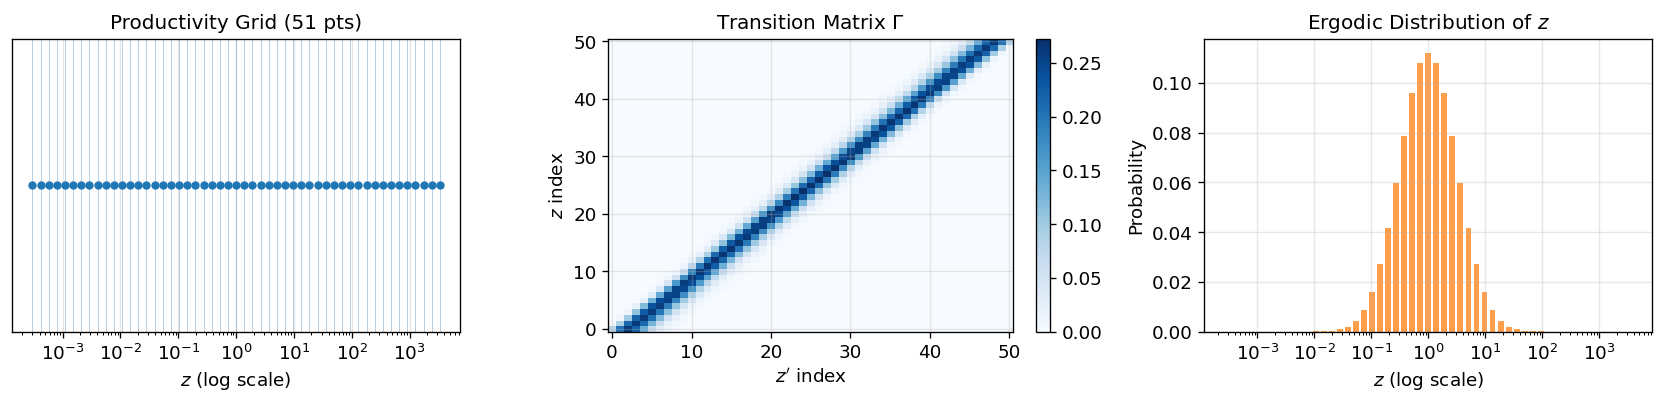

In [2]:
# Common parameters
PARAMS = dict(n_z=51, rho_z=0.90, sigma_z=0.50, theta=0.64, phi=0.5, kappa=5.0, beta=0.80)

# Discretize productivity for visualization
log_z, Pi_z = rouwenhorst(PARAMS["n_z"], PARAMS["rho_z"], PARAMS["sigma_z"])
z_grid = np.exp(log_z)
ergodic = stationary_distribution(Pi_z)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# (a) Productivity grid — log x-axis so points are visible
axes[0].plot(z_grid, np.ones_like(z_grid), "C0o", ms=4)
for zv in z_grid:
    axes[0].axvline(zv, color="C0", lw=0.4, alpha=0.5)
axes[0].set_xscale("log")
axes[0].set(xlabel="$z$ (log scale)", ylabel="", yticks=[], title=f"Productivity Grid ({PARAMS['n_z']} pts)")
axes[0].set_ylim(0.8, 1.2)

# (b) Transition matrix
im = axes[1].imshow(Pi_z, aspect="auto", cmap="Blues", origin="lower")
axes[1].set(xlabel="$z'$ index", ylabel="$z$ index", title="Transition Matrix $\\Gamma$")
fig.colorbar(im, ax=axes[1], fraction=0.046)

# (c) Ergodic distribution — log x-axis, proper bar widths
lz = np.log(z_grid)
dlz = np.diff(lz, prepend=lz[0] - (lz[1]-lz[0]))  # spacing in log space
bar_w = z_grid * (1 - np.exp(-dlz)) * 0.85        # linear width ≈ z * Δlog(z)
axes[2].bar(z_grid, ergodic, width=bar_w, color="C1", alpha=0.75, edgecolor="none")
axes[2].set_xscale("log")
axes[2].set(xlabel="$z$ (log scale)", ylabel="Probability", title="Ergodic Distribution of $z$")

fig.tight_layout()
plt.show()

## 2. Inelastic Labor Supply Equilibrium ($N^s = 1$)

In [3]:
ss = solve_hopenhayn_ss(**PARAMS, labor_supply="inelastic", N_supply=1.0, verbose=True)
print(ss.summary())

  eval   1: w=0.010000, z*_idx=  0, V^e=+3.185415e+05
  eval   2: w=10.000000, z*_idx= 29, V^e=-4.360253e+00
  eval   3: w=0.010000, z*_idx=  0, V^e=+3.185415e+05
  eval   4: w=10.000000, z*_idx= 29, V^e=-4.360253e+00
  eval   5: w=9.999863, z*_idx= 29, V^e=-4.360225e+00
  eval   6: w=5.004932, z*_idx= 26, V^e=-1.207352e+00
  eval   7: w=3.092212, z*_idx= 24, V^e=+5.291598e+00
  eval   8: w=4.649593, z*_idx= 26, V^e=-5.542542e-01
  eval   9: w=4.376625, z*_idx= 26, V^e=+5.010352e-02
  eval  10: w=4.399255, z*_idx= 26, V^e=-3.985514e-03
  eval  11: w=4.397588, z*_idx= 26, V^e=-2.637147e-05
  eval  12: w=4.397577, z*_idx= 26, V^e=+1.010596e-10
  eval  13: w=4.397577, z*_idx= 26, V^e=-6.401116e-08
Hopenhayn (1992) Stationary Equilibrium
  Labor supply: inelastic
  w = 4.397577,  r = 0.250000
  z* = 1.3833 (grid index 26)
  M (entrants) = 0.0836
  Exit rate = 0.1910
  Active firms = 0.3542
  Y = 6.8712,  N = 1.0000,  C = 6.2759
  Aggregate profits = 1.8783
  Walras residual = 0.00e+00
  Ou

### Figure 1: Value Function $V(z)$ (Proposition 27.3, Property 1)

$V(z)$ should be strictly increasing in $z$ for active firms.

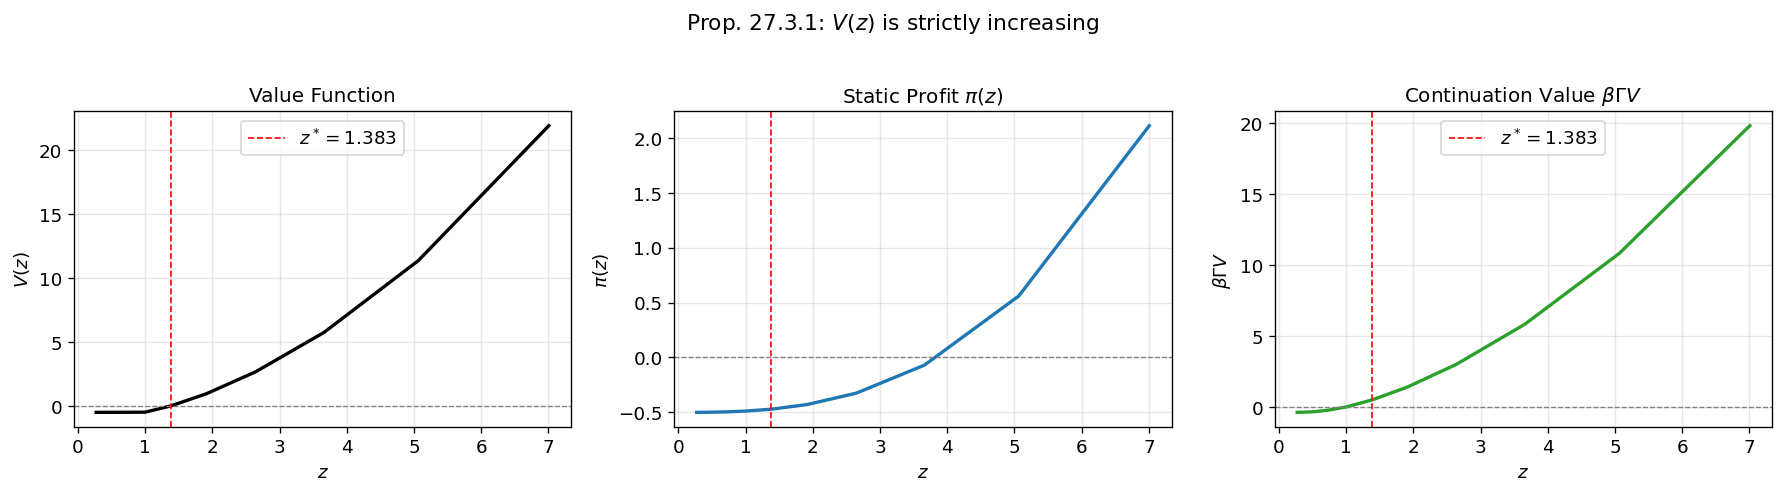

V strictly increasing on active firms: True


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tight window around z*: a few points below and above the exit threshold
i_lo = max(0, ss.z_star_idx - 5)
i_hi = min(len(ss.z_grid) - 1, ss.z_star_idx + 6)

z_f  = ss.z_grid[i_lo:i_hi]
V_f  = ss.V[i_lo:i_hi]
pi_f = ss.profit[i_lo:i_hi]
cv_f = ss.cont_value[i_lo:i_hi]

# (a) Value function
axes[0].plot(z_f, V_f, "k-", lw=2)
axes[0].axhline(0, color="gray", ls="--", lw=0.8)
axes[0].axvline(ss.z_star, color="r", ls="--", lw=1, label=f"$z^* = {ss.z_star:.3f}$")
axes[0].set(xlabel="$z$", ylabel="$V(z)$", title="Value Function")
axes[0].legend()

# (b) Profit function
axes[1].plot(z_f, pi_f, "C0-", lw=2)
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].axvline(ss.z_star, color="r", ls="--", lw=1)
axes[1].set(xlabel="$z$", ylabel="$\\pi(z)$", title="Static Profit $\\pi(z)$")

# (c) Continuation value
axes[2].plot(z_f, cv_f, "C2-", lw=2)
axes[2].axhline(0, color="gray", ls="--", lw=0.8)
axes[2].axvline(ss.z_star, color="r", ls="--", lw=1, label=f"$z^* = {ss.z_star:.3f}$")
axes[2].set(xlabel="$z$", ylabel="$\\beta \\Gamma V$", title="Continuation Value $\\beta\\Gamma V$")
axes[2].legend()

fig.suptitle("Prop. 27.3.1: $V(z)$ is strictly increasing", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

active_V = ss.V[ss.z_star_idx:]
print(f"V strictly increasing on active firms: {np.all(np.diff(active_V) > 0)}")

### Figure 2: iid vs Stochastically Monotone (Macro Bible Fig. 27.2)

Compare the value function and continuation value under the actual stochastically monotone $\Gamma$ versus an iid counterfactual (where $\Gamma_{ij} = \pi^*_j$ for all $i$).

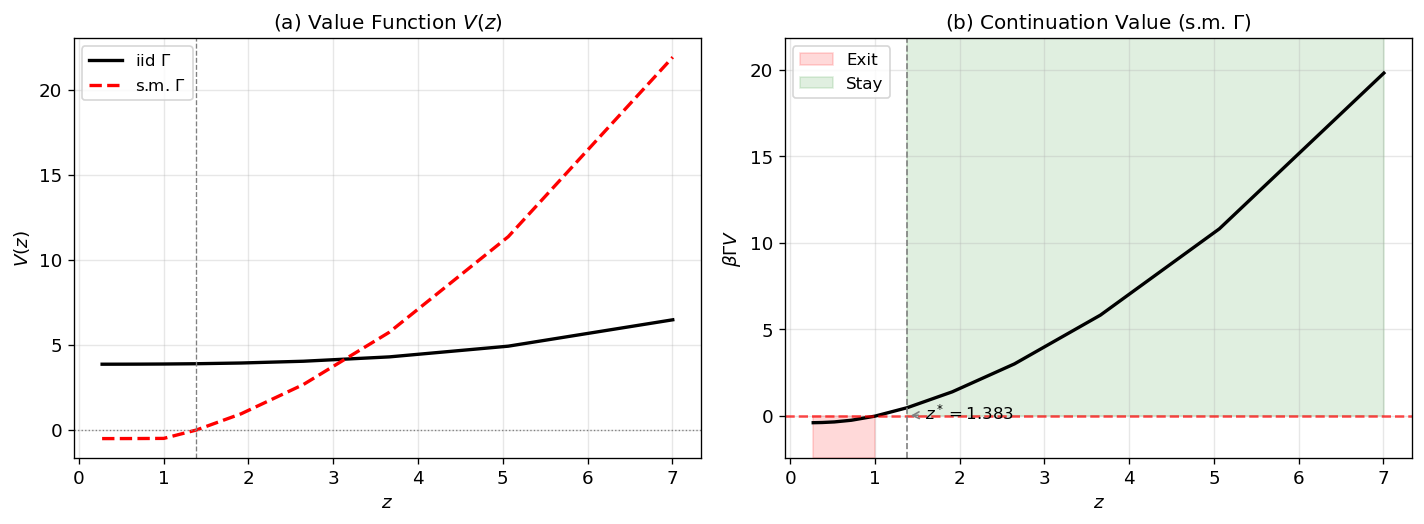

In [5]:
# Construct iid counterfactual: every row of Pi is the ergodic distribution
Pi_iid = np.tile(ergodic, (len(ergodic), 1))

V_iid, zs_iid = _solve_firm_problem(Pi_iid, ss.profit, ss.params["beta"])

# Tight window around z*
i_lo = max(0, ss.z_star_idx - 5)
i_hi = min(len(ss.z_grid) - 1, ss.z_star_idx + 6)

z_f   = ss.z_grid[i_lo:i_hi]
V_sm  = ss.V[i_lo:i_hi]
V_id  = V_iid[i_lo:i_hi]
cv_sm = ss.cont_value[i_lo:i_hi]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Value functions
axes[0].plot(z_f, V_id, "k-",  lw=2, label="iid $\\Gamma$")
axes[0].plot(z_f, V_sm, "r--", lw=2, label="s.m. $\\Gamma$")
axes[0].axhline(0, color="gray", ls=":", lw=0.8)
axes[0].axvline(ss.z_star, color="gray", ls="--", lw=0.8)
axes[0].set(xlabel="$z$", ylabel="$V(z)$", title="(a) Value Function $V(z)$")
axes[0].legend(fontsize=10)

# (b) Continuation value with shaded regions — compute y-bounds from data
cv_min = cv_sm.min()
cv_max = cv_sm.max()
pad = (cv_max - cv_min) * 0.10
y_lo, y_hi = cv_min - pad, cv_max + pad

axes[1].fill_between(z_f, y_lo, 0,    where=z_f < ss.z_star,
                     alpha=0.15, color="red",   label="Exit")
axes[1].fill_between(z_f, 0,    y_hi, where=z_f >= ss.z_star,
                     alpha=0.12, color="green", label="Stay")
axes[1].plot(z_f, cv_sm, "k-", lw=2)
axes[1].axhline(0, color="r", ls="--", lw=1.5, alpha=0.7)
axes[1].axvline(ss.z_star, color="gray", ls="--", lw=1)
axes[1].annotate(
    f"$z^* = {ss.z_star:.3f}$",
    xy=(ss.z_star, 0),
    xytext=(ss.z_star * 1.15, cv_min * 0.5),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="gray"),
)
axes[1].set_ylim(y_lo, y_hi)
axes[1].set(xlabel="$z$", ylabel="$\\beta \\Gamma V$",
            title="(b) Continuation Value (s.m. $\\Gamma$)")
axes[1].legend(fontsize=10)

fig.tight_layout()
plt.show()

### Figure 3: Stationary Distribution $\lambda^*(z)$

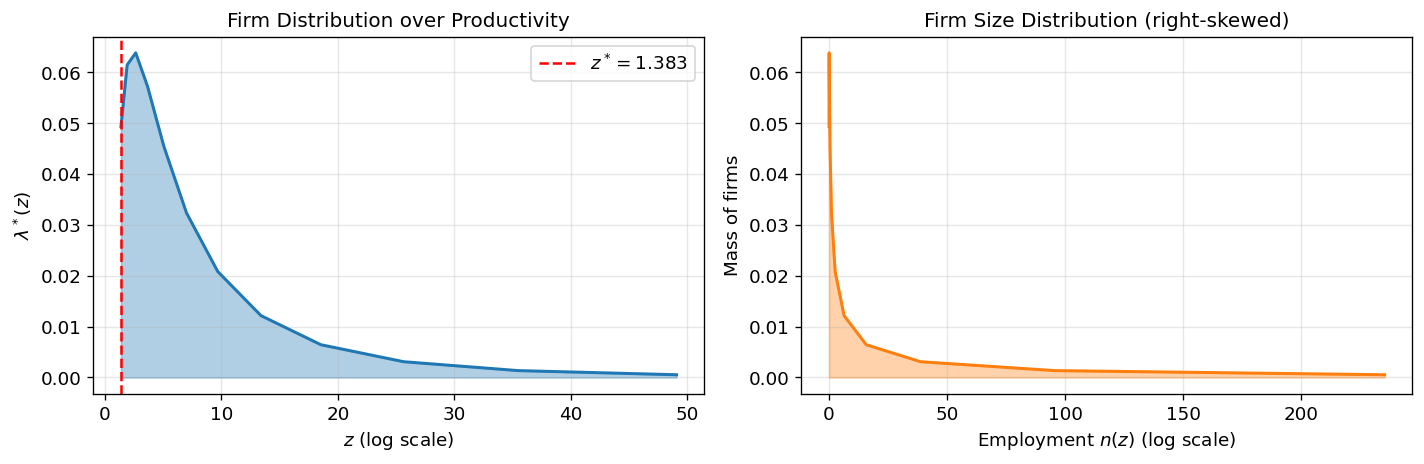

Skewness of employment-weighted distribution: 14.676


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Active firms up to z = 50
lam_act = ss.lambda_star[ss.z_star_idx:]
z_act   = ss.z_grid[ss.z_star_idx:]
n_act   = ss.labor_demand[ss.z_star_idx:]

mask     = z_act <= 50.0
z_show   = z_act[mask]
lam_show = lam_act[mask]
n_show   = n_act[mask]

# (a) Density over productivity (log x-axis)
axes[0].fill_between(z_show, 0, lam_show, alpha=0.35, color="C0")
axes[0].plot(z_show, lam_show, "C0-", lw=1.8)
axes[0].axvline(ss.z_star, color="r", ls="--", lw=1.5, label=f"$z^* = {ss.z_star:.3f}$")
# axes[0].set_xscale("log")
axes[0].set(xlabel="$z$ (log scale)", ylabel="$\\lambda^*(z)$",
            title="Firm Distribution over Productivity")
axes[0].legend()

# (b) Density over employment (log x-axis)
n_pos = n_show.clip(min=1e-6)
axes[1].fill_between(n_pos, 0, lam_show, alpha=0.35, color="C1")
axes[1].plot(n_pos, lam_show, "C1-", lw=1.8)
# axes[1].set_xscale("log")
axes[1].set(xlabel="Employment $n(z)$ (log scale)", ylabel="Mass of firms",
            title="Firm Size Distribution (right-skewed)")

fig.tight_layout()
plt.show()

n_mean = np.average(n_show, weights=lam_show)
n_var  = np.average((n_show - n_mean)**2, weights=lam_show)
n_skew = np.average((n_show - n_mean)**3, weights=lam_show) / n_var**1.5
print(f"Skewness of employment-weighted distribution: {n_skew:.3f}")

## 3. Comparative Statics (Proposition 27.3, Property 2)

$z^*$ should be increasing in $w$: higher wages reduce profits and force less productive firms out.

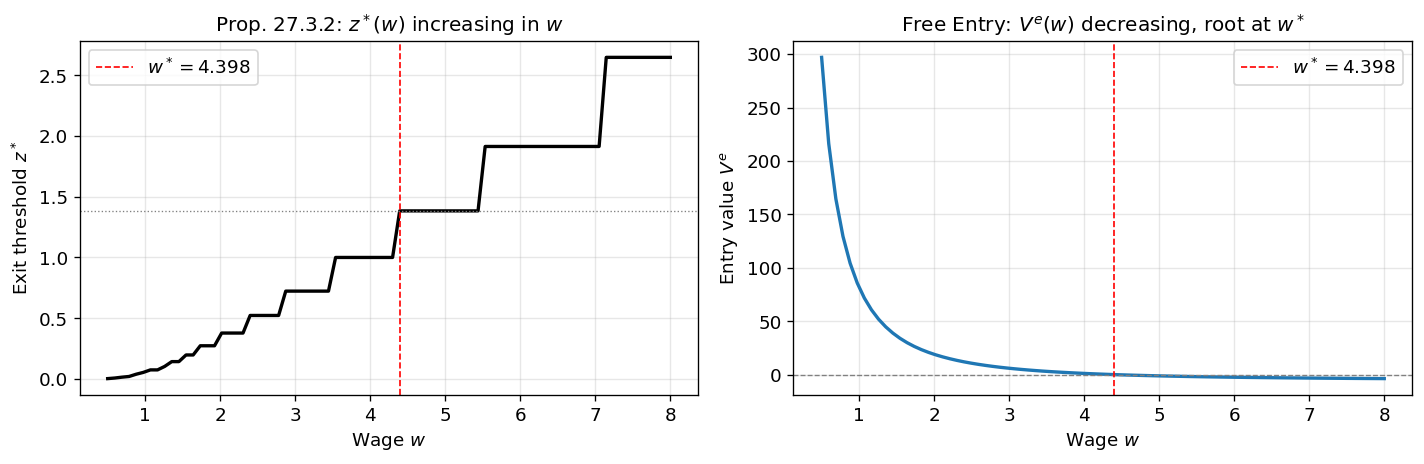

In [7]:
w_grid = np.linspace(0.5, 8.0, 80)
z_star_vec = np.zeros_like(w_grid)
Ve_vec = np.zeros_like(w_grid)

for i, w in enumerate(w_grid):
    profit_w = hopenhayn_profit(ss.z_grid, w, PARAMS["theta"], PARAMS["phi"])
    V_w, zs_w = _solve_firm_problem(ss.Pi_z, profit_w, PARAMS["beta"])
    z_star_vec[i] = ss.z_grid[zs_w] if zs_w < len(ss.z_grid) else ss.z_grid[-1]
    Ve_vec[i] = hopenhayn_entry_value(V_w, ss.G, PARAMS["kappa"], PARAMS["beta"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) z*(w)
axes[0].plot(w_grid, z_star_vec, "k-", lw=2)
axes[0].axvline(ss.w, color="r", ls="--", lw=1, label=f"$w^* = {ss.w:.3f}$")
axes[0].axhline(ss.z_star, color="gray", ls=":", lw=0.8)
axes[0].set(xlabel="Wage $w$", ylabel="Exit threshold $z^*$", 
            title="Prop. 27.3.2: $z^*(w)$ increasing in $w$")
axes[0].legend()

# (b) V^e(w)
axes[1].plot(w_grid, Ve_vec, "C0-", lw=2)
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].axvline(ss.w, color="r", ls="--", lw=1, label=f"$w^* = {ss.w:.3f}$")
axes[1].set(xlabel="Wage $w$", ylabel="Entry value $V^e$",
            title="Free Entry: $V^e(w)$ decreasing, root at $w^*$")
axes[1].legend()

fig.tight_layout()
plt.show()

## 4. Expected Firm Size Increases with Age (Proposition 27.3, Property 3)

Start a cohort of entrants distributed as $G$, apply the sub-Markov kernel $Q$ forward in time, normalize survivors at each age, and compute the expected employment $E[n(z) \mid \text{age}=t, \text{survived}]$.

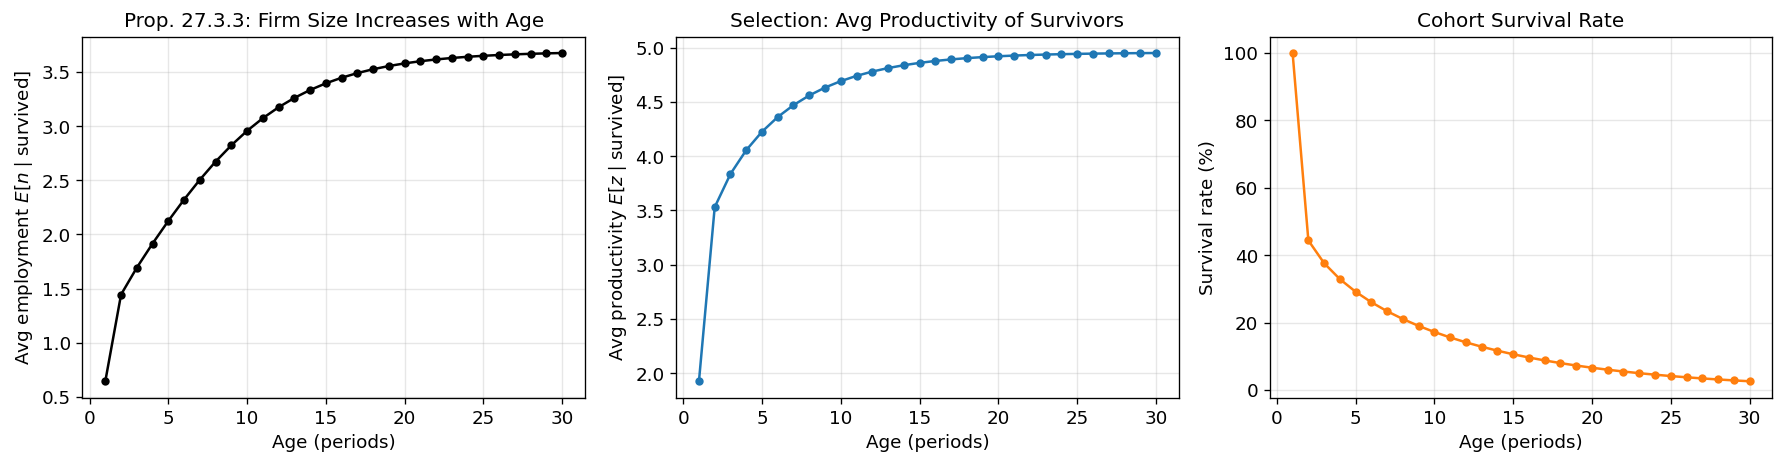

Avg size at age 1: 0.64
Avg size at age 10: 2.96
Avg size at age 20: 3.58
Monotonically increasing: True


In [8]:
T_cohort = 30  # track cohort for 30 periods
avg_size_by_age = np.zeros(T_cohort)
survival_rate = np.zeros(T_cohort)
avg_z_by_age = np.zeros(T_cohort)

# Cohort starts as G, apply Q' each period
cohort = ss.G.copy()
for t in range(T_cohort):
    mass = cohort.sum()
    survival_rate[t] = mass / ss.G.sum()
    if mass > 1e-15:
        cohort_norm = cohort / mass  # normalize to get conditional distribution
        avg_size_by_age[t] = np.dot(cohort_norm, ss.labor_demand)
        avg_z_by_age[t] = np.dot(cohort_norm, ss.z_grid)
    cohort = ss.Q.T @ cohort  # one period forward under sub-Markov Q

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ages = np.arange(1, T_cohort + 1)

axes[0].plot(ages, avg_size_by_age, "ko-", ms=4, lw=1.5)
axes[0].set(xlabel="Age (periods)", ylabel="Avg employment $E[n \\mid \\text{survived}]$",
            title="Prop. 27.3.3: Firm Size Increases with Age")

axes[1].plot(ages, avg_z_by_age, "C0o-", ms=4, lw=1.5)
axes[1].set(xlabel="Age (periods)", ylabel="Avg productivity $E[z \\mid \\text{survived}]$",
            title="Selection: Avg Productivity of Survivors")

axes[2].plot(ages, survival_rate * 100, "C1o-", ms=4, lw=1.5)
axes[2].set(xlabel="Age (periods)", ylabel="Survival rate (%)",
            title="Cohort Survival Rate")

fig.tight_layout()
plt.show()

print(f"Avg size at age 1: {avg_size_by_age[0]:.2f}")
print(f"Avg size at age 10: {avg_size_by_age[9]:.2f}")
print(f"Avg size at age 20: {avg_size_by_age[19]:.2f}")
print(f"Monotonically increasing: {np.all(np.diff(avg_size_by_age[:20]) > 0)}")

## 5. Elastic Labor Supply

Three household closures that all deliver the same equilibrium wage $w^*$ (free entry pins it):
- **Inelastic** ($N^s = 1$): baseline from Section 2
- **Elastic / lotteries** ($\max\; \log C - aN$): Hopenhayn-Rogerson (1993) with employment lotteries
- **Separable / Pset 8** ($\max\; \frac{C^{1-\sigma}}{1-\sigma} - \frac{N^{1+\gamma}}{1+\gamma}$, $\sigma = \gamma = 2$): convex labor disutility, no lotteries

Only $M$ (and hence aggregate scale) differs across closures.

In [9]:
# Elastic (lotteries): max log(C) - aN
ss_el = solve_hopenhayn_ss(**PARAMS, labor_supply="elastic", a_disutility=1.0, gamma_hh=1.0)
print(ss_el.summary())
print(f"\nHH FOC: w = a*C? w={ss_el.w:.6f}, a*C={1.0*ss_el.C:.6f}")
print(f"Budget: C = wN + Pi? C={ss_el.C:.6f}, wN+Pi={ss_el.w*ss_el.N + ss_el.Pi_agg:.6f}")

# Separable (Pset 8): u = C^{1-sigma}/(1-sigma) - N^{1+nu}/(1+nu), sigma = nu = 2
print("\n" + "="*60 + "\n")
ss_sep = solve_hopenhayn_ss(**PARAMS, labor_supply="separable", gamma_hh=2.0, nu_labor=2.0)
print(ss_sep.summary())
foc_lhs = ss_sep.C**(-2.0) * ss_sep.w
foc_rhs = ss_sep.N**2.0
print(f"\nFOC check: C^{{-2}}w = {foc_lhs:.6f},  N^2 = {foc_rhs:.6f}")
print(f"Budget: C = {ss_sep.C:.6f},  wN + Pi = {ss_sep.w * ss_sep.N + ss_sep.Pi_agg:.6f}")

Hopenhayn (1992) Stationary Equilibrium
  Labor supply: elastic
  w = 4.397577,  r = 0.250000
  z* = 1.3833 (grid index 26)
  M (entrants) = 0.0586
  Exit rate = 0.1910
  Active firms = 0.2482
  Y = 4.8147,  N = 0.7007,  C = 4.3976
  Aggregate profits = 1.3161
  Walras residual = 8.88e-16
  Outer iterations = 13
  Elapsed = 0.05s

HH FOC: w = a*C? w=4.397577, a*C=4.397577
Budget: C = wN + Pi? C=4.397577, wN+Pi=4.397577


Hopenhayn (1992) Stationary Equilibrium
  Labor supply: separable
  w = 4.397577,  r = 0.250000
  z* = 1.3833 (grid index 26)
  M (entrants) = 0.0484
  Exit rate = 0.1910
  Active firms = 0.2048
  Y = 3.9719,  N = 0.5781,  C = 3.6278
  Aggregate profits = 1.0857
  Walras residual = 4.44e-16
  Outer iterations = 13
  Elapsed = 0.01s

FOC check: C^{-2}w = 0.334143,  N^2 = 0.334143
Budget: C = 3.627774,  wN + Pi = 3.627774


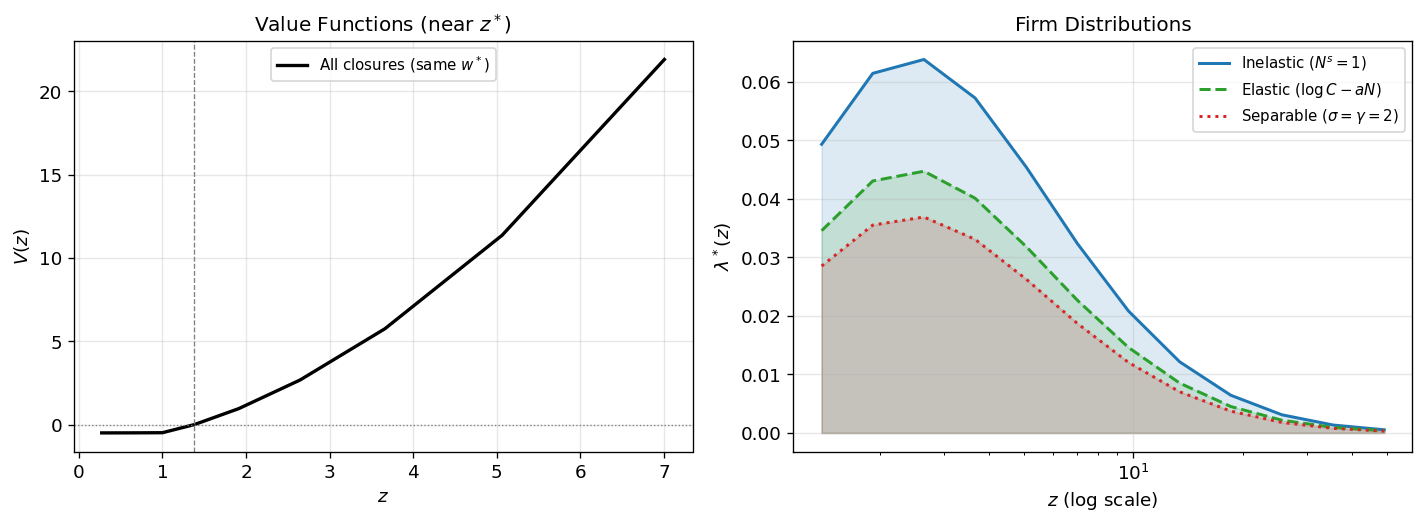

                  Inelastic      Elastic    Separable
-----------------------------------------------------
w*                   4.3976       4.3976       4.3976
z*                   1.3833       1.3833       1.3833
M                    0.0836       0.0586       0.0484
N                    1.0000       0.7007       0.5781
Y                    6.8712       4.8147       3.9719
C                    6.2759       4.3976       3.6278
Exit rate            0.1910       0.1910       0.1910


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Tight window around z* for value functions
i_lo = max(0, ss.z_star_idx - 5)
i_hi = min(len(ss.z_grid) - 1, ss.z_star_idx + 6)
z_f  = ss.z_grid[i_lo:i_hi]

# (a) Value functions — all three closures give same w* and hence same V
axes[0].plot(z_f, ss.V[i_lo:i_hi], "k-", lw=2, label="All closures (same $w^*$)")
axes[0].axhline(0, color="gray", ls=":", lw=0.8)
axes[0].axvline(ss.z_star, color="gray", ls="--", lw=0.8)
axes[0].set(xlabel="$z$", ylabel="$V(z)$", title="Value Functions (near $z^*$)")
axes[0].legend(fontsize=9)

# (b) Firm distributions — different scales due to different M
z_max = 50.0
cases = [
    (ss,     "C0", "-",  "Inelastic ($N^s=1$)"),
    (ss_el,  "C2", "--", "Elastic ($\\log C - aN$)"),
    (ss_sep, "C3", ":",  "Separable ($\\sigma=\\gamma=2$)"),
]
for s, color, ls, label in cases:
    lam = s.lambda_star[s.z_star_idx:]
    z   = s.z_grid[s.z_star_idx:]
    mask = z <= z_max
    axes[1].fill_between(z[mask], 0, lam[mask], alpha=0.15, color=color)
    axes[1].plot(z[mask], lam[mask], color=color, ls=ls, lw=1.8, label=label)
axes[1].set_xscale("log")
axes[1].set(xlabel="$z$ (log scale)", ylabel="$\\lambda^*(z)$", title="Firm Distributions")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

# Summary table
header = f"{'':14s} {'Inelastic':>12s} {'Elastic':>12s} {'Separable':>12s}"
print(header)
print("-" * len(header))
for lbl, v1, v2, v3 in zip(
    ["w*", "z*", "M", "N", "Y", "C", "Exit rate"],
    [ss.w, ss.z_star, ss.M, ss.N, ss.Y, ss.C, ss.exit_rate],
    [ss_el.w, ss_el.z_star, ss_el.M, ss_el.N, ss_el.Y, ss_el.C, ss_el.exit_rate],
    [ss_sep.w, ss_sep.z_star, ss_sep.M, ss_sep.N, ss_sep.Y, ss_sep.C, ss_sep.exit_rate],
):
    print(f"{lbl:14s} {v1:12.4f} {v2:12.4f} {v3:12.4f}")

## 6. Robustness: Varying $\phi$ and $\kappa$

/var/folders/jn/33qbdrsn2055lsl5jw84hjph0000gn/T/ipykernel_46499/908362276.py:9: UserWarning: No firm exits (z_star_idx=0, likely phi=0). lambda_hat set to ergodic distribution.
  ss_tmp = solve_hopenhayn_ss(**{**PARAMS, "phi": phi_val}, labor_supply="inelastic")


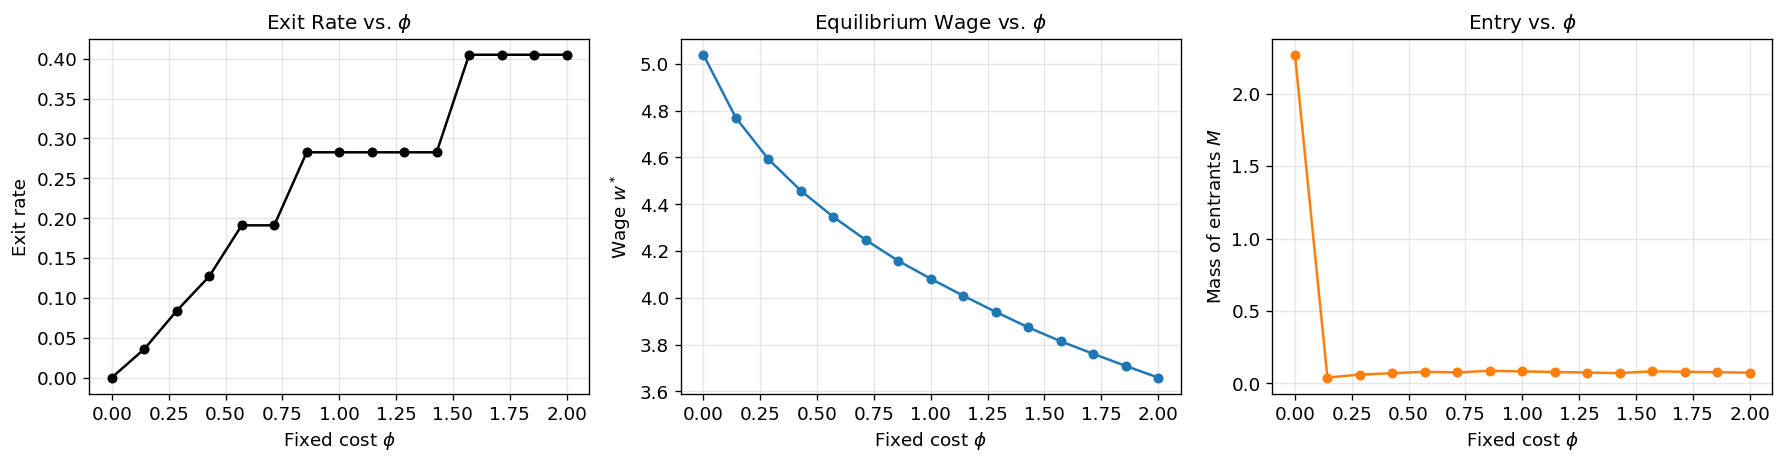

In [11]:
# Vary phi (fixed cost): trace exit rates and wage
phi_grid = np.linspace(0.0, 2.0, 15)
exit_rates_phi = []
wages_phi = []
M_phi = []

for phi_val in phi_grid:
    try:
        ss_tmp = solve_hopenhayn_ss(**{**PARAMS, "phi": phi_val}, labor_supply="inelastic")
        exit_rates_phi.append(ss_tmp.exit_rate)
        wages_phi.append(ss_tmp.w)
        M_phi.append(ss_tmp.M)
    except Exception:
        exit_rates_phi.append(np.nan)
        wages_phi.append(np.nan)
        M_phi.append(np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(phi_grid, exit_rates_phi, "ko-", ms=5)
axes[0].set(xlabel="Fixed cost $\\phi$", ylabel="Exit rate", title="Exit Rate vs. $\\phi$")

axes[1].plot(phi_grid, wages_phi, "C0o-", ms=5)
axes[1].set(xlabel="Fixed cost $\\phi$", ylabel="Wage $w^*$", title="Equilibrium Wage vs. $\\phi$")

axes[2].plot(phi_grid, M_phi, "C1o-", ms=5)
axes[2].set(xlabel="Fixed cost $\\phi$", ylabel="Mass of entrants $M$", title="Entry vs. $\\phi$")

fig.tight_layout()
plt.show()

## 7. Hopenhayn–Rogerson (1993): Firing Taxes

Extends the vanilla Hopenhayn model by adding a per-worker firing cost:
$$g(n_{-1}, n) = \tau \cdot \max\{0, n_{-1} - n\}.$$

The firm's state becomes two-dimensional: $(n_{-1}, z)$, where $n_{-1}$ is last period's employment. The Bellman equation is

$$V(n_{-1}, z) = \max_{n \geq 0} \Big\{ zn^\theta - wn - \phi - \tau \max\{0, n_{-1}-n\} + \beta \max\big(\mathbb{E}[V(n, z') \mid z], \; -\tau n\big) \Big\},$$

where the inner $\max$ captures the end-of-period exit decision: a firm continuing with $n$ workers into next period can either operate (value $\mathbb{E}[V(n, z')]$) or exit and pay the lump-sum firing cost $\tau n$. Entrants arrive with $n_{-1} = 0$, so they face no firing cost in their first period.

**Key difference from Hopenhayn (1992):**
1. The value function no longer solves by matrix inversion; we use VFI with Howard improvement on the 2D grid.
2. Firms exhibit an **inaction region**: small productivity changes don't trigger any hiring or firing.
3. Firing taxes reshape the size distribution and reduce the equilibrium wage (to preserve free entry).

The firing tax revenue is rebated to the household as a lump-sum transfer, so it nets out of the goods market clearing.

In [12]:
from hetmacro.models.hopenhayn_rogerson import solve_hopenhayn_rogerson_ss

# HR1993 uses the same calibration as the vanilla model, plus the employment grid
PARAMS_HR = dict(
    n_z=51, rho_z=0.90, sigma_z=0.50,
    n_n=101, n_min=1e-3, n_max=10_000.0,
    theta=0.64, phi=0.5, kappa=5.0, beta=0.80,
)

# Baseline: tau = 0 (should reduce exactly to vanilla Hopenhayn 1992)
ss_hr0 = solve_hopenhayn_rogerson_ss(**PARAMS_HR, tau=0.0, labor_supply="inelastic",
                                         verbose=True)

print("=== Reduction check: tau=0 should match vanilla Hopenhayn 1992 ===\n")
print(f"{'':12s} {'Vanilla':>12s} {'HR tau=0':>12s} {'rel diff':>10s}")
for name, v1, v2 in [
    ("w*", ss.w, ss_hr0.w),
    ("exit rate", ss.exit_rate, ss_hr0.exit_rate),
    ("M", ss.M, ss_hr0.M),
    ("N", ss.N, ss_hr0.N),
    ("Y", ss.Y, ss_hr0.Y),
    ("C", ss.C, ss_hr0.C),
]:
    rel = abs(v1 - v2) / max(abs(v1), 1e-12)
    print(f"{name:12s} {v1:12.5f} {v2:12.5f} {rel:10.3%}")

print(f"\nHR solver elapsed: {ss_hr0.elapsed:.2f}s")
print(f"VFI iterations (final): {ss_hr0.n_vfi_iter}")
print(f"Walras residual: {ss_hr0.walras_residual:.2e}")

  eval   1: w=0.010000, VFI_iter=  51, V^e=+2.414141e+03
  eval   2: w=10.000000, VFI_iter=  51, V^e=-4.363614e+00
  eval   3: w=0.010000, VFI_iter=  51, V^e=+2.414141e+03
  eval   4: w=10.000000, VFI_iter=  51, V^e=-4.363614e+00
  eval   5: w=9.981975, VFI_iter=  26, V^e=-4.359832e+00
  eval   6: w=4.995988, VFI_iter=  26, V^e=-1.221039e+00
  eval   7: w=3.059854, VFI_iter=  26, V^e=+5.277208e+00
  eval   8: w=4.632183, VFI_iter=  26, V^e=-5.586602e-01
  eval   9: w=4.354718, VFI_iter=  26, V^e=+5.113112e-02
  eval  10: w=4.377983, VFI_iter=  26, V^e=-3.867764e-03
  eval  11: w=4.376347, VFI_iter=  26, V^e=-2.149490e-05
  eval  12: w=4.376338, VFI_iter=  26, V^e=-9.032131e-09
  eval  13: w=4.376338, VFI_iter=  19, V^e=+6.202292e-07
=== Reduction check: tau=0 should match vanilla Hopenhayn 1992 ===

                  Vanilla     HR tau=0   rel diff
w*                4.39758      4.37634     0.483%
exit rate         0.19102      0.19102     0.000%
M                 0.08364      0.08484 

### 7.1 Comparative Statics across Firing Taxes

Solve the equilibrium for a grid of firing taxes $\tau \in \{0, 0.1, 0.3, 0.5, 1.0\}$ (all inelastic labor) and compare the equilibrium objects. Under HR1993 in GE, higher $\tau$ reduces the equilibrium wage $w^*$ to preserve free entry, since firms face higher effective labor costs.

In [13]:
tau_grid = [0.0, 0.5, 1.0, 2.0, 5.0]
ss_hr_list = []
for tau_val in tau_grid:
    ss_tmp = solve_hopenhayn_rogerson_ss(**PARAMS_HR, tau=tau_val, labor_supply="inelastic")
    ss_hr_list.append(ss_tmp)

# Summary table
print(f"{'tau':>6s} {'w*':>10s} {'M':>10s} {'Exit':>10s} {'Y':>10s} {'C':>10s} {'Firing T':>10s}")
print("-" * 66)
for tau_val, s in zip(tau_grid, ss_hr_list):
    print(f"{tau_val:6.2f} {s.w:10.4f} {s.M:10.4f} {s.exit_rate:10.4f} "
          f"{s.Y:10.4f} {s.C:10.4f} {s.firing_total:10.4f}")

   tau         w*          M       Exit          Y          C   Firing T
------------------------------------------------------------------
  0.00     4.3763     0.0848     0.1910     6.8811     6.2773     0.0000
  0.50     4.1919     0.0840     0.1910     6.8461     6.2482     0.2238
  1.00     4.0258     0.0799     0.1910     6.6878     6.1194     0.4035
  2.00     3.7598     0.0620     0.1270     6.4597     5.9370     0.6367
  5.00     3.2395     0.0490     0.1270     5.4840     5.0708     0.9573


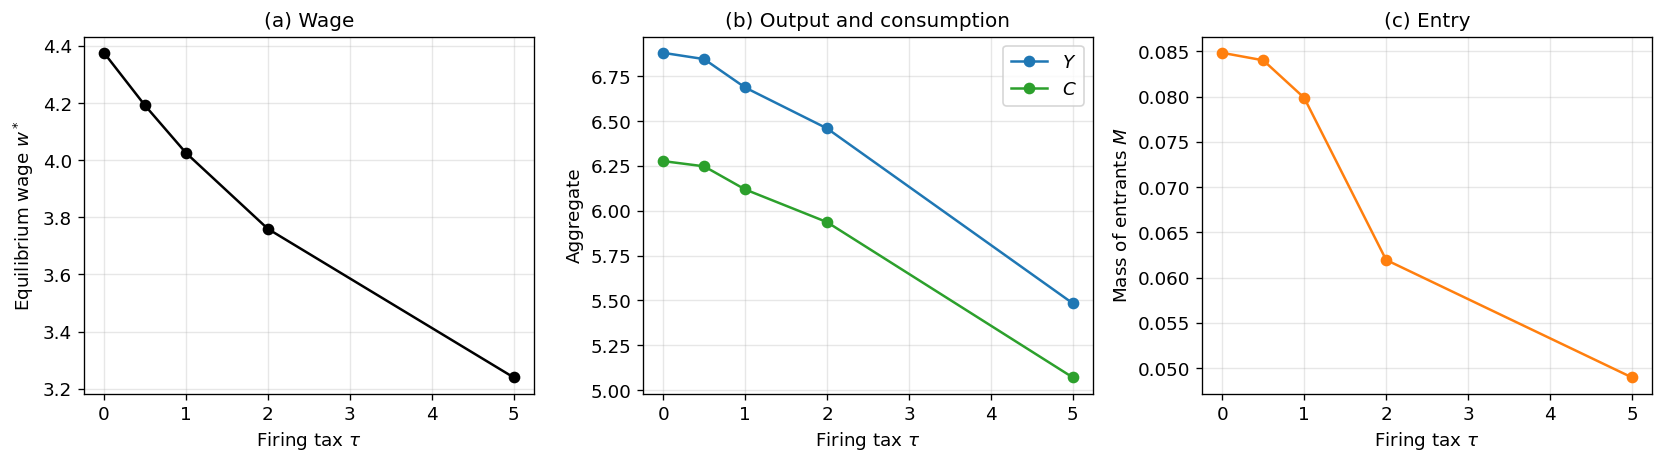

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

tau_arr = np.array(tau_grid)
w_arr = np.array([s.w for s in ss_hr_list])
Y_arr = np.array([s.Y for s in ss_hr_list])
C_arr = np.array([s.C for s in ss_hr_list])
M_arr = np.array([s.M for s in ss_hr_list])

axes[0].plot(tau_arr, w_arr, "ko-", ms=6)
axes[0].set(xlabel="Firing tax $\\tau$", ylabel="Equilibrium wage $w^*$",
            title="(a) Wage")

axes[1].plot(tau_arr, Y_arr, "C0o-", ms=6, label="$Y$")
axes[1].plot(tau_arr, C_arr, "C2o-", ms=6, label="$C$")
axes[1].set(xlabel="Firing tax $\\tau$", ylabel="Aggregate",
            title="(b) Output and consumption")
axes[1].legend()

axes[2].plot(tau_arr, M_arr, "C1o-", ms=6)
axes[2].set(xlabel="Firing tax $\\tau$", ylabel="Mass of entrants $M$",
            title="(c) Entry")

fig.tight_layout()
plt.show()

### 7.2 Policy Function and Inaction Region

At $\tau > 0$, firms face a discrete kink in their cost function at $n = n_{-1}$: lowering employment below $n_{-1}$ triggers a firing cost, while keeping it at $n_{-1}$ is costless. This creates an **inaction region** in $(n_{-1}, z)$ space: a range of productivity shocks small enough that the firm prefers to sit on its current employment rather than pay the firing cost.

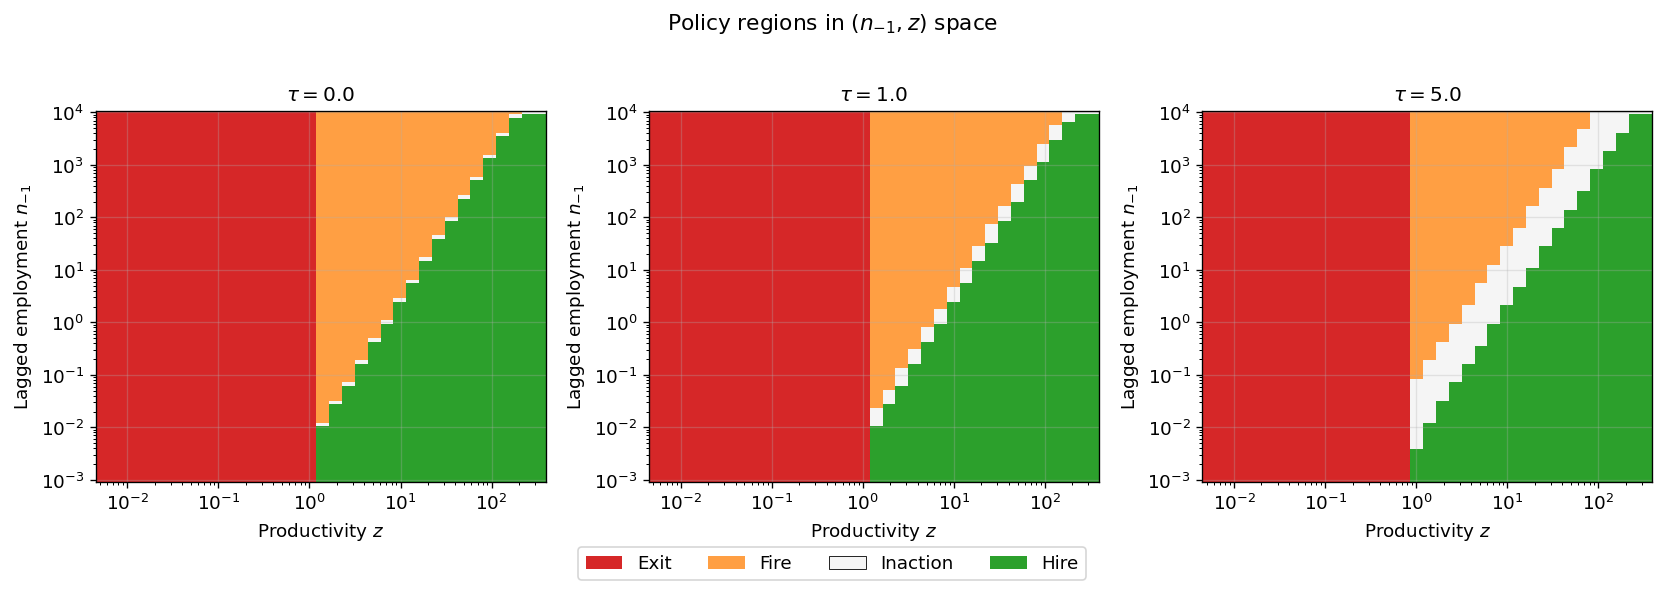


Inaction mass share among active firms:
  tau= 0.0: 26.42%
  tau= 0.5: 26.42%
  tau= 1.0: 26.42%
  tau= 2.0: 47.27%
  tau= 5.0: 65.88%


In [15]:
def inaction_mask(s):
    """Boolean (n_n, n_z) mask: True where chosen n equals n_prev (and firm stays)."""
    n_prev = s.n_grid[:, None]
    return (np.abs(s.n_policy_level - n_prev) < 1e-10) & (~s.exit_mask)

def hire_mask(s):
    n_prev = s.n_grid[:, None]
    return (s.n_policy_level > n_prev + 1e-10) & (~s.exit_mask)

def fire_mask(s):
    n_prev = s.n_grid[:, None]
    return (s.n_policy_level < n_prev - 1e-10) & (~s.exit_mask)

# Use the full range of tau values; focus on a (n_prev, z) window with mass
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ss_ref = ss_hr_list[-1]  # largest tau, which has the largest inaction region
lam = ss_ref.lambda_star
mass_n = lam.sum(axis=1)
mass_z = lam.sum(axis=0)
i_lo = max(0, int(np.argmax(mass_n > 1e-6)) - 2)
i_hi = min(len(ss_ref.n_grid), len(ss_ref.n_grid) - int(np.argmax(mass_n[::-1] > 1e-6)) + 2)
j_lo = max(0, int(np.argmax(mass_z > 1e-6)) - 2)
j_hi = min(len(ss_ref.z_grid), len(ss_ref.z_grid) - int(np.argmax(mass_z[::-1] > 1e-6)) + 2)

def plot_regions(ax, ss_tmp, title):
    exit_m = ss_tmp.exit_mask[i_lo:i_hi, j_lo:j_hi].astype(float)
    hire_m = hire_mask(ss_tmp)[i_lo:i_hi, j_lo:j_hi].astype(float)
    fire_m = fire_mask(ss_tmp)[i_lo:i_hi, j_lo:j_hi].astype(float)
    inaction_m = inaction_mask(ss_tmp)[i_lo:i_hi, j_lo:j_hi].astype(float)

    # Color code: 0=exit, 1=fire, 2=inaction, 3=hire
    code = np.zeros_like(exit_m)
    code[exit_m > 0.5] = 0
    code[fire_m > 0.5] = 1
    code[inaction_m > 0.5] = 2
    code[hire_m > 0.5] = 3

    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(["#d62728", "#ff9f43", "#f5f5f5", "#2ca02c"])
    ax.pcolormesh(
        ss_tmp.z_grid[j_lo:j_hi], ss_tmp.n_grid[i_lo:i_hi],
        code, cmap=cmap, vmin=-0.5, vmax=3.5, shading="auto",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set(xlabel="Productivity $z$", ylabel="Lagged employment $n_{-1}$", title=title)

plot_regions(axes[0], ss_hr_list[0], f"$\\tau = {tau_grid[0]}$")
plot_regions(axes[1], ss_hr_list[2], f"$\\tau = {tau_grid[2]}$")
plot_regions(axes[2], ss_hr_list[4], f"$\\tau = {tau_grid[4]}$")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d62728", label="Exit"),
    Patch(facecolor="#ff9f43", label="Fire"),
    Patch(facecolor="#f5f5f5", label="Inaction", edgecolor="k", linewidth=0.5),
    Patch(facecolor="#2ca02c", label="Hire"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Policy regions in $(n_{-1}, z)$ space", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Mass share of inaction (among active firms)
print("\nInaction mass share among active firms:")
for tau_val, s in zip(tau_grid, ss_hr_list):
    mask = inaction_mask(s)
    mass_in = (s.lambda_star * mask).sum()
    mass_active = (s.lambda_star * (~s.exit_mask)).sum()
    print(f"  tau={tau_val:4.1f}: {mass_in/mass_active:.2%}")

#### Policy and Value Function: The $(S,s)$ Inaction Band

At $\tau > 0$ the firm faces a kink at $n = n_{-1}$: contracting triggers a per-worker cost $\tau$, while staying put is free. This creates an inaction region in $(\log z,\, \log n)$ space. The two boundaries are the dynamic hire threshold $f'(z,n) + \beta\mathbb{E}[V_n] = w$ (red) and the dynamic fire threshold $f'(z,n) + \beta\mathbb{E}[V_n] = w - \tau$ (blue). Between them the firm keeps $n' = n_{-1}$; outside the band it tracks the nearer boundary. Both boundaries are extracted directly from the computed policy function.


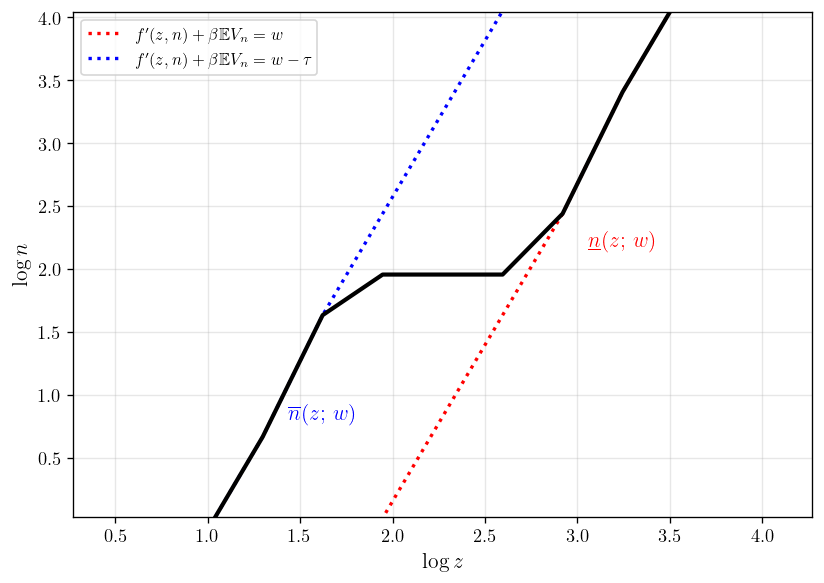

In [17]:
# Inaction band: policy n'(n_{-1}, z) for a single n_{-1} slice.
# Boundaries extracted from the computed policy (not the static FOC).

k_ref   = 4  # tau = 5.0 (widest band)
s_ref   = ss_hr_list[k_ref]
theta_r = PARAMS_HR['theta']
w_r     = s_ref.w
tau_r   = tau_grid[k_ref]
n_grid_r = s_ref.n_grid

# ── Extract dynamic boundaries from the policy function ────────────────
n_z_r = len(s_ref.z_grid)
n_hire_dyn = np.full(n_z_r, np.nan)
n_fire_dyn = np.full(n_z_r, np.nan)

for j in range(n_z_r):
    active_j = ~s_ref.exit_mask[:, j]
    if not active_j.any():
        continue
    pol_j   = s_ref.n_policy_level[active_j, j]
    nprev_j = n_grid_r[active_j]
    hiring  = pol_j > nprev_j * (1 + 1e-6)
    firing  = pol_j < nprev_j * (1 - 1e-6)
    if hiring.any():
        n_hire_dyn[j] = pol_j[hiring][-1]
    if firing.any():
        n_fire_dyn[j] = pol_j[firing][0]

valid = (~np.isnan(n_hire_dyn) & ~np.isnan(n_fire_dyn)
         & (n_hire_dyn > 0) & (n_fire_dyn > 0))
log_z_bd   = np.log(s_ref.z_grid[valid])
log_n_hire = np.log(n_hire_dyn[valid])
log_n_fire = np.log(n_fire_dyn[valid])

# ── Pick an n_prev in the middle of the band ───────────────────────────
mid_j = len(log_z_bd) // 2
target_log_n = (log_n_hire[mid_j] + log_n_fire[mid_j]) / 2
idx_mid = np.argmin(np.abs(np.log(n_grid_r) - target_log_n))
n_prev  = n_grid_r[idx_mid]
active  = ~s_ref.exit_mask[idx_mid, :]

# ── Plot ───────────────────────────────────────────────────────────────
with plt.rc_context({'text.usetex': True,
                     'text.latex.preamble': r'\usepackage{amsmath,amssymb}'}):
    fig, ax = plt.subplots(figsize=(7, 5))

    # Policy function (solid black).
    ax.plot(np.log(s_ref.z_grid[active]),
            np.log(s_ref.n_policy_level[idx_mid, active]),
            'k-', lw=2.5, zorder=5)

    # Dynamic hire boundary (red dotted) with FOC legend.
    ax.plot(log_z_bd, log_n_hire, 'r:', lw=2,
            label=r"$f'(z,n) + \beta\mathbb{E}V_n = w$")

    # Dynamic fire boundary (blue dotted) with FOC legend.
    ax.plot(log_z_bd, log_n_fire, 'b:', lw=2,
            label=r"$f'(z,n) + \beta\mathbb{E}V_n = w - \tau$")

    # Annotations.
    z_center = log_z_bd[mid_j]
    x_lo, x_hi = z_center - 2.0, z_center + 2.0

    x_label_hire = x_lo + 0.70 * (x_hi - x_lo)
    x_label_fire = x_lo + 0.250 * (x_hi - x_lo)
    idx_lh = np.argmin(np.abs(log_z_bd - x_label_hire))
    idx_lf = np.argmin(np.abs(log_z_bd - x_label_fire))

    ax.annotate(r'$\underline{n}(z;\, w)$',
                xy=(log_z_bd[idx_lh], log_n_hire[idx_lh]),
                xytext=(15, -20), textcoords='offset points',
                fontsize=13, color='red')

    ax.annotate(r'$\overline{n}(z;\, w)$',
                xy=(log_z_bd[idx_lf], log_n_fire[idx_lf]),
                xytext=(15, 10), textcoords='offset points',
                fontsize=13, color='blue')

    # Zoom around the inaction region.
    ax.set_xlim(x_lo, x_hi)
    y_lo = log_n_hire[mid_j] - 0.8
    y_hi = log_n_fire[mid_j] + 0.8
    ax.set_ylim(y_lo, y_hi)

    ax.set_xlabel(r'$\log z$', fontsize=13)
    ax.set_ylabel(r'$\log n$', fontsize=13)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    # fig.savefig(
    #     '../../../../../../Macro Bible/Parts_and_chapters/Heterogeneity/'
    #     'Firm_heterogeneity/figures/hopenhayn_rogerson_inaction_Ss.pdf',
    #     bbox_inches='tight')
    plt.show()


### 7.3 Stationary Distributions under Firing Taxes

How does the firing tax reshape the firm size distribution? Plot the marginal distribution of employment (summed over $z$) for each $\tau$ and compare.

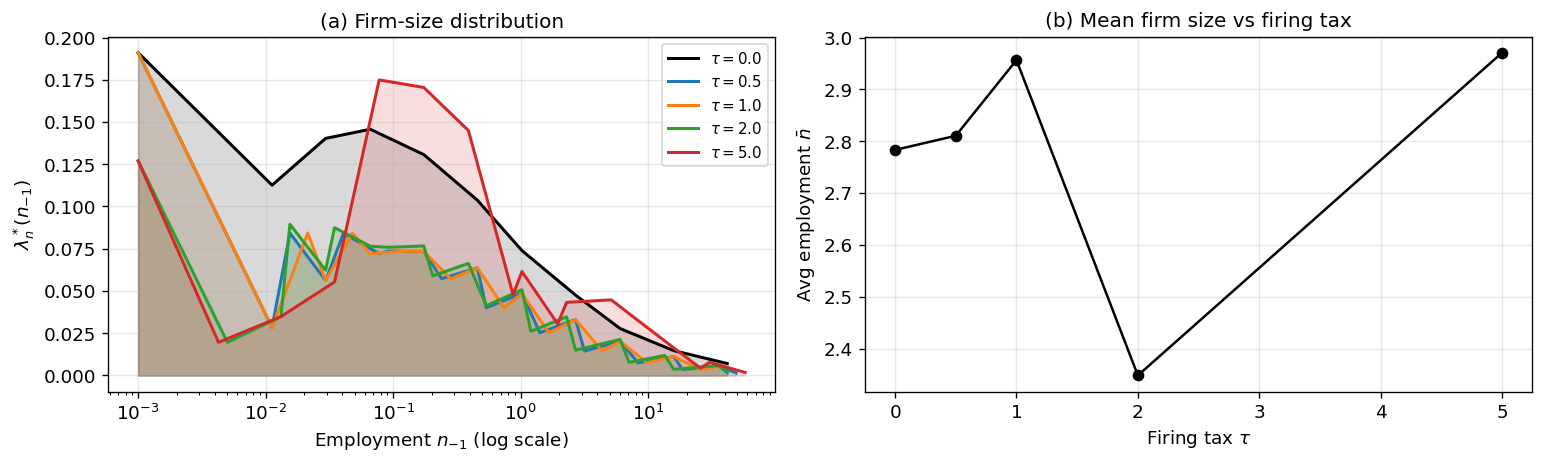

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Determine common n_upper: 99.5th percentile of tau=0 mass
lam0 = ss_hr_list[0].lambda_star / ss_hr_list[0].lambda_star.sum()
lam0_n = lam0.sum(axis=1)
n_cum = np.cumsum(lam0_n)
n_upper_idx = int(np.searchsorted(n_cum, 0.995)) + 2
n_upper = ss_hr_list[0].n_grid[min(n_upper_idx, len(ss_hr_list[0].n_grid) - 1)]

colors = ['k', 'C0', 'C1', 'C2', 'C3']

# (a) Firm-size distribution (marginal over n_{-1})
for tau_val, s, color in zip(tau_grid, ss_hr_list, colors):
    lam  = s.lambda_star / s.lambda_star.sum()
    mass_n = lam.sum(axis=1)                     # marginal over z
    mask = (s.n_grid <= n_upper) & (mass_n > 1e-10)
    n_show   = s.n_grid[mask]
    lam_show = mass_n[mask]
    axes[0].fill_between(n_show, 0, lam_show, alpha=0.15, color=color)
    axes[0].plot(n_show, lam_show, '-', color=color, lw=1.8,
                 label=f'$\\tau = {tau_val:.1f}$')

axes[0].set_xscale('log')
axes[0].set(xlabel='Employment $n_{-1}$ (log scale)',
            ylabel='$\\lambda^*_n(n_{-1})$',
            title='(a) Firm-size distribution')
axes[0].legend(fontsize=9)

# (b) Mean firm size vs tau
avg_size = np.array([
    (s.lambda_star * s.n_policy_level * (~s.exit_mask)).sum()
    / ((s.lambda_star * (~s.exit_mask)).sum())
    for s in ss_hr_list
])
axes[1].plot(tau_arr, avg_size, 'ko-', ms=6)
axes[1].set(xlabel='Firing tax $\\tau$', ylabel='Avg employment $\\bar n$',
            title='(b) Mean firm size vs firing tax')

fig.tight_layout()
plt.show()


#### Joint Distribution $\lambda^*(n_{-1}, z)$ — Zoomed View

Filled-contour plot of the stationary joint distribution over productivity $z$ and lagged employment $n_{-1}$, clipped to the region that contains 99\% of the mass. The dashed red curve is the frictionless optimum $n^*(z)$; the dotted diagonal is the inaction locus $n' = n_{-1}$. At $\tau = 0$ the mass concentrates along the frictionless curve. As $\tau$ rises the distribution thickens around the diagonal.

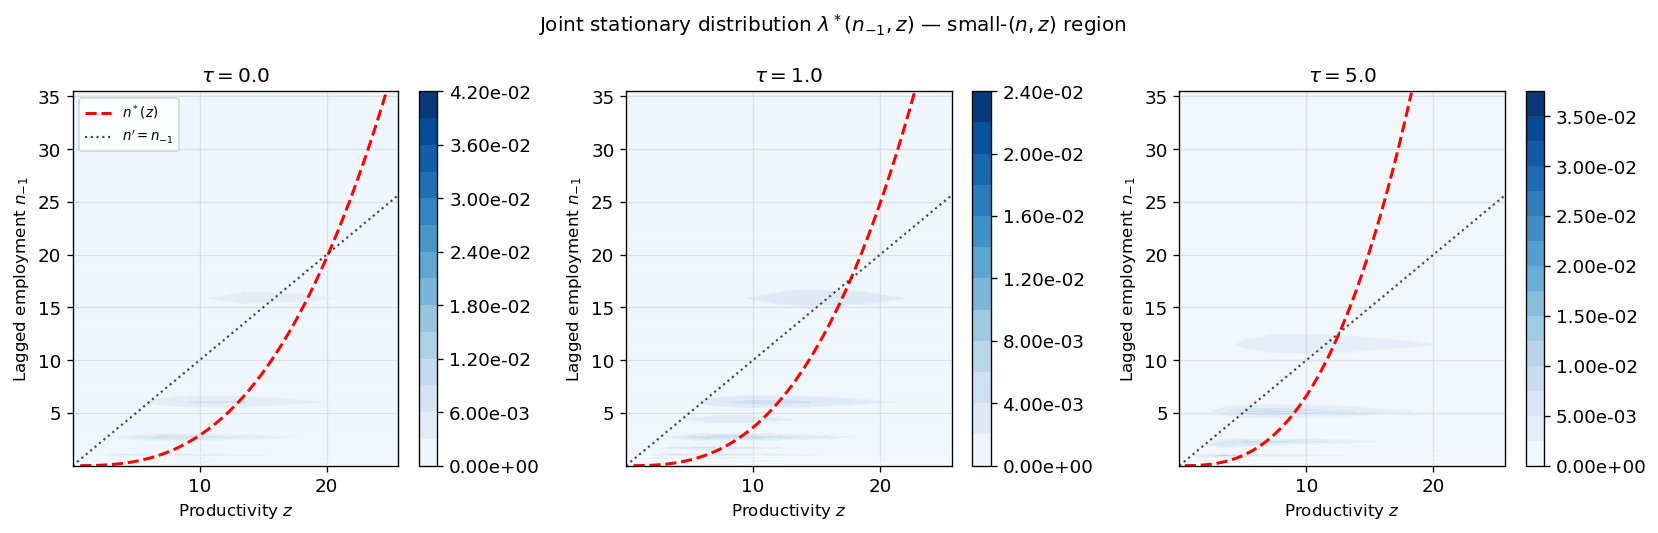

In [18]:
tau_show = [0, 2, 4]   # tau = 0.0, 1.0, 5.0

# Common zoom bounds: use 99th-percentile of each marginal from the widest case (tau=5)
s_wide = ss_hr_list[tau_show[-1]]
lam_wide = s_wide.lambda_star / s_wide.lambda_star.sum()
z_idx_max = int(np.searchsorted(np.cumsum(lam_wide.sum(axis=0)), 0.99)) + 2
n_idx_max = int(np.searchsorted(np.cumsum(lam_wide.sum(axis=1)), 0.99)) + 2
z_idx_max = min(z_idx_max, len(s_wide.z_grid) - 1)
n_idx_max = min(n_idx_max, len(s_wide.n_grid) - 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, k in zip(axes, tau_show):
    s = ss_hr_list[k]
    lam = s.lambda_star / s.lambda_star.sum()

    # Zoom to common window
    z_show = s.z_grid[:z_idx_max]
    n_show = s.n_grid[:n_idx_max]
    lam_zoom = lam[:n_idx_max, :z_idx_max]         # (n_n_zoom, n_z_zoom)

    X, Y = np.meshgrid(z_show, n_show)
    cf = ax.contourf(X, Y, lam_zoom, levels=14, cmap='Blues')
    ax.contour(X, Y, lam_zoom, levels=14, colors='white', linewidths=0.4, alpha=0.5)
    plt.colorbar(cf, ax=ax, format='%.2e')

    # Frictionless n*(z)
    z_line = np.linspace(z_show.min(), z_show.max(), 300)
    n_star = (PARAMS_HR['theta'] * z_line / s.w) ** (1.0 / (1.0 - PARAMS_HR['theta']))
    in_range = (n_star >= n_show.min()) & (n_star <= n_show.max())
    ax.plot(z_line[in_range], n_star[in_range], 'r--', lw=1.8, label="$n^*(z)$")

    # Inaction diagonal n' = n_{-1}
    diag_hi = min(z_show.max(), n_show.max())
    diag_lo = max(z_show.min(), n_show.min())
    ax.plot([diag_lo, diag_hi], [diag_lo, diag_hi], 'k:', lw=1.3, alpha=0.7,
            label="$n' = n_{-1}$")

    ax.set_xlabel('Productivity $z$', fontsize=10)
    ax.set_ylabel('Lagged employment $n_{-1}$', fontsize=10)
    ax.set_title(f'$\\tau = {tau_grid[k]:.1f}$', fontsize=12)

axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Joint stationary distribution $\\lambda^*(n_{-1}, z)$ — small-$(n, z)$ region',
             fontsize=12)
plt.tight_layout()
plt.show()


### 7.4 Welfare and Misallocation

With firing taxes, TFP falls because firms are constrained to carry employment levels away from their frictionless optimum. Compute the welfare loss from $\tau = 0$ to $\tau = 0.5$ in consumption-equivalent units, and report an aggregate TFP-style measure $Y / N^\theta$ to quantify the misallocation loss.

In [19]:
# TFP-like measure: Y / (M_active * n_avg)^theta, normalized to tau=0
theta_val = PARAMS_HR["theta"]
TFP = np.array([s.Y / (s.N ** theta_val) for s in ss_hr_list])
TFP_norm = TFP / TFP[0]

print(f"{'tau':>6s} {'TFP':>10s} {'TFP (% of tau=0)':>18s} {'C (% of tau=0)':>18s}")
print("-" * 56)
C0 = ss_hr_list[0].C
for tau_val, s, tfp_n in zip(tau_grid, ss_hr_list, TFP_norm):
    print(f"{tau_val:6.2f} {TFP[tau_grid.index(tau_val)]:10.4f} "
          f"{tfp_n:17.2%} {s.C/C0:17.2%}")

# Consumption-equivalent welfare loss (static utility, inelastic labor)
# u(C) = log(C) => CE = (C_tau / C_0) - 1
print()
print("Consumption-equivalent welfare change (log utility):")
for tau_val, s in zip(tau_grid, ss_hr_list):
    ce = s.C / C0 - 1
    print(f"  tau={tau_val:.2f}: {ce:+.2%}")

   tau        TFP   TFP (% of tau=0)     C (% of tau=0)
--------------------------------------------------------
  0.00     6.8811           100.00%           100.00%
  0.50     6.8461            99.49%            99.54%
  1.00     6.6878            97.19%            97.48%
  2.00     6.4597            93.88%            94.58%
  5.00     5.4840            79.70%            80.78%

Consumption-equivalent welfare change (log utility):
  tau=0.00: +0.00%
  tau=0.50: -0.46%
  tau=1.00: -2.52%
  tau=2.00: -5.42%
  tau=5.00: -19.22%


## 8. Virgiliu Midrigan's Closure: Fixed Mass + Labor Market Clearing

Virgiliu's Pset 8 (MATLAB code in `Material/.../PSets/Pset 8/.../Inelastic Labor/`) solves a **structurally simpler version** of Hopenhayn-Rogerson with four differences from Section 7's free-entry HR1993:

| | Our HR (Section 7) | Virgiliu (this section) |
|---|---|---|
| Firm mass | Endogenous (free entry $V^e=0$) | **Fixed $M=1$** |
| Exit option | Yes (max with $-\tau n$) | **None** |
| Fixed operating cost $\phi$ | Yes | **0** |
| Entry cost $\kappa$ | Yes | **0** |
| Wage closure | Free entry | **$\int n\, d\lambda = N^s$** |
| Production | $z n^\theta$ | $z n^\eta$ (same form, $\eta$ = his $\theta$) |

His **baseline calibration** (from [`start.m`](../../../Material/Course_Materials/Virgiliu_Midrigan/PSets/Pset%208/extracted_code/Code%20for%20Students/Inelastic%20Labor/start.m), lines 9-15):

- $\beta = 0.95$, $\eta = 0.90$, $\rho_z = 0.90$, $\sigma_z = 0.50$, $\tau = 0.5$
- $n_n = 251$, $n_z = 51$

This is a *much more DRS-shallow* calibration than ours ($\theta=0.64$ in Sections 1-7), and the combination of near-linearity with no fixed cost means the firing tax mostly operates through the **wage margin** rather than exit.

Our `hetmacro.models.hopenhayn_rogerson_virgiliu` implements his closure directly, reusing the existing VFI plumbing (`_build_flow_tensor` with $\phi=0$) and a new power-iteration routine for the joint ergodic distribution on $(n_{-1}, z)$.

### 8.1 Solve at Virgiliu's Baseline and $\tau=0$ Smoke Check

At $\tau=0$ the model collapses to a frictionless static problem and the solver should recover the closed-form labor-market-clearing wage

$$w^* = \eta \left(\frac{\mathbb{E}[z^{1/(1-\eta)}]}{N^s}\right)^{1-\eta}.$$

This is a strong internal check on the VFI and forward iteration.

In [20]:
from hetmacro.models.hopenhayn_rogerson_virgiliu import (
    solve_virgiliu_ss, _frictionless_wage,
)

PARAMS_VIRG = dict(
    n_z=51, rho_z=0.90, sigma_z=0.50,
    n_n=251,
    eta=0.90, beta=0.95,
)

# Analytic LMC wage at tau = 0.
# Under the PS8 revenue form z^(1-eta)*n^eta the inelastic labor-market
# clearing wage is   w = eta * (E[z] / N_target)^(1-eta).
from hetmacro.markov import rouwenhorst, stationary_distribution
log_z, Pi_z_v = rouwenhorst(51, 0.90, 0.50)
z_v = np.exp(log_z)
erg_v = stationary_distribution(Pi_z_v)
w_analytic = _frictionless_wage(z_v, erg_v, eta=0.90, N_target=1.0)
print(f"Analytic frictionless w* at tau=0 = {w_analytic:.6f}")

# Solve at tau = 0 (smoke check)
ss_v0 = solve_virgiliu_ss(**PARAMS_VIRG, tau=0.0, labor_supply="inelastic", tol=1e-5)
print(f"Solver w* at tau=0               = {ss_v0.w:.6f}")
print(f"Relative error                    = {(ss_v0.w-w_analytic)/w_analytic:+.2e}")
print(f"|N - 1| (grid quantization)       = {abs(ss_v0.N - 1):.2e}")

# Solve at Virgiliu's baseline tau = 0.5
print()
ss_v = solve_virgiliu_ss(**PARAMS_VIRG, tau=0.5, labor_supply="inelastic", tol=1e-5)
print(ss_v.summary())


Analytic frictionless w* at tau=0 = 0.960926
Solver w* at tau=0               = 0.960926
Relative error                    = +3.00e-09
|N - 1| (grid quantization)       = 6.00e-08

Hopenhayn (Virgiliu PS8 closure) Stationary Equilibrium
  Labor supply: inelastic
  tau (firing tax) = 0.5000
  w = 0.941433,  r = 0.052632
  N = 0.999881,  Y = 1.049379,  C = 1.049379
  Net firm profits = 0.091242
  Firing flow      = 0.016815
  TFP            = 1.049491
  TFP (frictionless) = 1.067696
  Misallocation loss = +1.7051%
  Aggregate labor wedge = 0.986588
  |dW|  residual = 5.58e-06
  Walras residual = 0.00e+00
  VFI iter (final) = 31
  Outer iter (wage)= 12
  Elapsed = 31.38s


### 8.2 $\tau$ Sweep under Virgiliu's Calibration

Compare the comparative statics of the firing tax against Section 7.1 (free-entry HR at $\theta=0.64, \beta=0.80, \phi=0.5, \kappa=5$).

In [21]:
tau_grid_v = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0]
ss_v_list = []
for tau_val in tau_grid_v:
    s = solve_virgiliu_ss(**PARAMS_VIRG, tau=tau_val, labor_supply="inelastic", tol=1e-5)
    ss_v_list.append(s)

print(f"{'tau':>6} {'w*':>10} {'N':>8} {'Y':>10} {'TFP':>10} {'misalloc%':>11} {'firing':>9}")
print("-" * 72)
for tau_val, s in zip(tau_grid_v, ss_v_list):
    print(
        f"{tau_val:6.2f} {s.w:10.4f} {s.N:8.4f} {s.Y:10.4f} "
        f"{s.TFP:10.4f} {100*s.misallocation_loss:+10.3f}% {s.firing_total:9.4f}"
    )


   tau         w*        N          Y        TFP   misalloc%    firing
------------------------------------------------------------------------
  0.00     0.9609   1.0000     1.0677     1.0677     -0.000%    0.0000
  0.10     0.9512   0.9998     1.0637     1.0639     +0.360%    0.0091
  0.25     0.9450   0.9999     1.0580     1.0581     +0.898%    0.0142
  0.50     0.9414   0.9999     1.0494     1.0495     +1.705%    0.0168
  1.00     0.9435   0.9999     1.0357     1.0358     +2.984%    0.0157
  2.00     0.9622   1.0002     1.0182     1.0180     +4.656%    0.0082


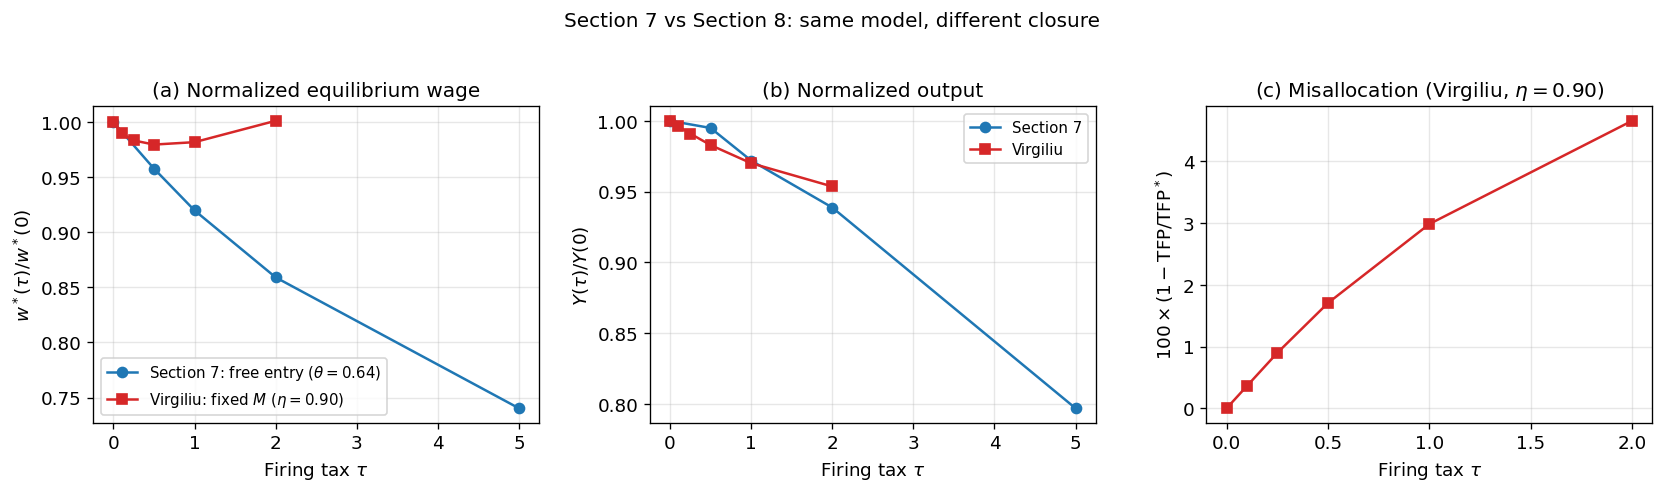

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

tau_arr_v = np.array(tau_grid_v)
w_arr_v = np.array([s.w for s in ss_v_list])
Y_arr_v = np.array([s.Y for s in ss_v_list])
misalloc_v = 100 * np.array([s.misallocation_loss for s in ss_v_list])

# Normalize wages so the two closures are on the same axis (baseline = 1.0 at tau=0)
w0_baseline = ss_hr_list[0].w
w0_virg = ss_v_list[0].w

axes[0].plot(np.array(tau_grid),  [s.w / w0_baseline  for s in ss_hr_list], "C0o-", ms=6, label=r"Section 7: free entry ($\theta=0.64$)")
axes[0].plot(tau_arr_v,            w_arr_v / w0_virg,                     "C3s-", ms=6, label=r"Virgiliu: fixed $M$ ($\eta=0.90$)")
axes[0].set(xlabel=r"Firing tax $\tau$", ylabel=r"$w^*(\tau) / w^*(0)$",
            title="(a) Normalized equilibrium wage")
axes[0].legend(fontsize=9)

axes[1].plot(np.array(tau_grid), [s.Y / ss_hr_list[0].Y for s in ss_hr_list], "C0o-", ms=6, label="Section 7")
axes[1].plot(tau_arr_v,          Y_arr_v / Y_arr_v[0],                       "C3s-", ms=6, label="Virgiliu")
axes[1].set(xlabel=r"Firing tax $\tau$", ylabel=r"$Y(\tau) / Y(0)$",
            title="(b) Normalized output")
axes[1].legend(fontsize=9)

axes[2].plot(tau_arr_v, misalloc_v, "C3s-", ms=6)
axes[2].set(xlabel=r"Firing tax $\tau$", ylabel=r"$100 \times (1 - \mathrm{TFP}/\mathrm{TFP}^*)$",
            title=r"(c) Misallocation (Virgiliu, $\eta=0.90$)")

fig.suptitle("Section 7 vs Section 8: same model, different closure", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


### 8.3 Why the Firing Tax Looks Small in Virgiliu's Calibration

The near-linear production ($\eta=0.90$) means the frictionless labor demand is $n^*(z) = (\eta/w)^{1/(1-\eta)} \cdot z$, with coefficient $(\eta/w)^{10}$ that amplifies any $z$ shock by a factor of 10 in log-employment — *extremely* sensitive to $z$. Two diagnostics make this concrete:

1. **Gross churn** $\int |n - n_{-1}|\, d\lambda / N$: what fraction of aggregate employment gets reshuffled between firms each period, including hires and fires.
2. **Firing revenue / wage bill**: the direct fiscal burden of the firing tax, which measures how often $\tau$ actually bites.

Under Virgiliu's calibration with high curvature and no fixed cost, firms constantly track $n^*(z)$ period by period. Churn is enormous; firing revenue stays tiny because the bulk of reallocation is voluntary (small z shocks hire/fire small amounts), and those that would fire large numbers face only a linear cost. The **gross flow rate is almost completely insensitive to $\tau$** over the entire sweep.

Contrast this with Section 7, where $\theta=0.64$ and $\phi > 0$ produce a wide inaction band, and raising $\tau$ visibly reshapes exit and reallocation.

In [23]:
# Gross employment flows and firing-tax fiscal burden under Virgiliu's calibration.
#
# Under eta = 0.90, n*(z) = (eta/w)^{10} * z, so tiny z shocks produce huge
# desired employment changes. The gross churn rate (hires + fires, normalised
# by aggregate employment) is a cleaner diagnostic than a hire/fire/inaction
# classification on a discrete grid.

print(f"{'tau':>6} {'gross churn':>13} {'firing / wN':>13} {'mean |d log n|':>16}")
print("-" * 58)
for tau_val, s in zip(tau_grid_v, ss_v_list):
    n_prev = s.n_grid[:, None]
    n_next = s.n_policy_level
    lam = s.lambda_star
    delta = n_next - n_prev

    gross_flow = np.sum(lam * np.abs(delta)) / s.N   # hires + fires, per unit of N
    fiscal_burden = s.firing_total / (s.w * s.N)     # firing revenue as share of wage bill
    log_delta = np.log(np.maximum(n_next, 1e-12)) - np.log(n_prev)
    mean_logabs = np.sum(lam * np.abs(log_delta))

    print(f"{tau_val:6.2f} {100*gross_flow:11.2f}% {100*fiscal_burden:11.2f}% {mean_logabs:14.4f}")

   tau   gross churn   firing / wN   mean |d log n|
----------------------------------------------------------
  0.00       38.83%        0.00%         0.3942
  0.10       18.23%        0.96%         0.1837
  0.25       11.34%        1.50%         0.1135
  0.50        6.73%        1.79%         0.0666
  1.00        3.15%        1.67%         0.0308
  2.00        0.82%        0.86%         0.0079


### 8.4 Elastic Labor (Virgiliu's Separable Closure)

Virgiliu's `Elastic Labor/start.m` sets $u(C,N) = C^{1-\theta}/(1-\theta) - \psi N^{1+\gamma}/(1+\gamma)$ with $\theta = \gamma = 2$. The household FOC is

$$w\, C^{-\theta} = \psi\, N^\gamma,$$

and in this closure the firm side is unchanged — only the wage bisection target is now the $w$ consistent with household labor supply rather than $N^s=1$. Our solver handles this via `labor_supply="separable"`.

In [24]:
# Solve the elastic-labor (separable) closure at tau=0.5.
#
# Household: u(C, N) = C^(1-gamma_c)/(1-gamma_c) - psi * N^(1+gamma_n)/(1+gamma_n)
# FOC: w * C^(-gamma_c) = psi * N^(gamma_n), with C = Y (firing tax rebated).
# Matches Virgiliu's `Elastic Labor/start.m` parameter choice (theta=gamma=2).
#
# Note: the outer wage update uses a Newton-style closed form derived from the
# household FOC + the (approximately frictionless) firm side. Naive iteration
# w_new = psi*N^gn*Y^gc would diverge here because the slope at the FP is
# -(gamma_n + eta*gamma_c)/(1-eta) = -38 with these params.

ss_v_sep = solve_virgiliu_ss(
    **PARAMS_VIRG, tau=0.5,
    labor_supply="separable", gamma_c=2.0, gamma_n=2.0, psi=1.0,
    tol=1e-6,
)
print(ss_v_sep.summary())

# Sanity-check the household FOC: w*C^(-gamma_c) should equal psi*N^gamma_n.
foc_lhs = ss_v_sep.w * ss_v_sep.C ** (-2.0)
foc_rhs = 1.0 * ss_v_sep.N ** 2.0
print(f"\nHH FOC (should match): w*C^(-gamma_c) = {foc_lhs:.6f},  psi*N^gamma_n = {foc_rhs:.6f}")
print(f"Budget identity (C should equal Y): C = {ss_v_sep.C:.6f},  Y = {ss_v_sep.Y:.6f}")

Hopenhayn (Virgiliu PS8 closure) Stationary Equilibrium
  Labor supply: separable
    gamma_c = 2.000, gamma_n = 2.000, psi = 1.000
    HH FOC residual |w - psi*N^gn*C^gc| / w = 5.79e-05
  tau (firing tax) = 0.5000
  w = 0.945200,  r = 0.052632
  N = 0.960509,  Y = 1.012157,  C = 1.012157
  Net firm profits = 0.088092
  Firing flow      = 0.016192
  TFP            = 1.049535
  TFP (frictionless) = 1.067696
  Misallocation loss = +1.7010%
  Aggregate labor wedge = 0.986678
  |dW|  residual = 7.10e-07
  Walras residual = 0.00e+00
  VFI iter (final) = 16
  Outer iter (wage)= 16
  Elapsed = 38.26s

HH FOC (should match): w*C^(-gamma_c) = 0.922631,  psi*N^gamma_n = 0.922577
Budget identity (C should equal Y): C = 1.012157,  Y = 1.012157
